In [1]:
import numpy as np
import matplotlib.pyplot as plt

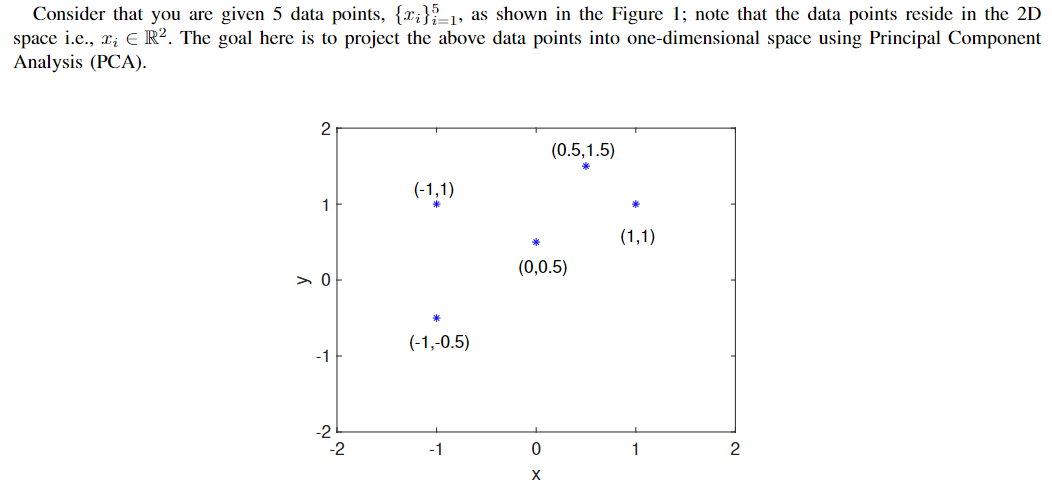

## 1) (Score: 20%) Briefly list the steps followed to perform the dimensionality reduction by applying PCA. What are the output(s) of PCA?

Given some data $x$ you can reduce the dimensionality down to match the $M$ dimensions of some value $y$ by following these steps:
1. Find the covariance matrix $S$ of the data $x$ (lecture 10 equation 4 - slide 254).
2. Find the data projection matrix formed by the eigenvectors of the $M$ largest eigenvalues of $S$.
3. Approximate the data points using only $M$ dimensions (lecture 10 equation 13 - slide 256).

The output of the PCA is then the reconstructed data along the principal components in only $M$ dimensions.

## 2) (Score: 40%) Using the steps listed above, apply PCA on the data set shown in Figure 1 and obtain the principal components as well as the associated variances of input data along those components.

In [2]:
M = 1
xs = np.array([[-1, 1],
               [0.5, 1.5],
               [0, 0.5],
               [1, 1],
               [-1, -0.5]])
N = len(xs)
D = len(xs.T)
x_bar = np.mean(xs, axis=0)

S = 0
for x_n in xs:
    S += np.outer(x_n - x_bar, x_n - x_bar)
S /= N

vals, vecs = np.linalg.eig(S)
var = sorted(vals, reverse=True)
U = np.array([vecs[:, i] for i in reversed(np.argsort(vals))]).T

xtilde = np.zeros_like(xs)
for n, x_n in enumerate(xs):
    for i in range(M, D):
        xtilde[n] -= np.inner(x_n - x_bar, U[:, i]) * U[:, i]
xtilde += xs
xtilde
var, U

([0.8824154027718932, 0.2175845972281068],
 array([[ 0.79710275, -0.6038437 ],
        [ 0.6038437 ,  0.79710275]]))

## 3) (Score: 20%) Plot the principal components (corresponding vectors) along with centered input data.

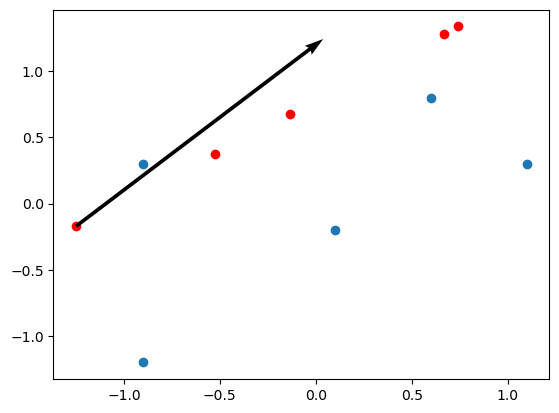

In [3]:
xcentered = xs - x_bar
plt.scatter(xtilde[:,0], xtilde[:,1], color='red')
plt.scatter(xcentered[:,0], xcentered[:,1])
plt.quiver(*np.min(xtilde, axis=0), *U[:, 0], scale=1.6)
plt.show()

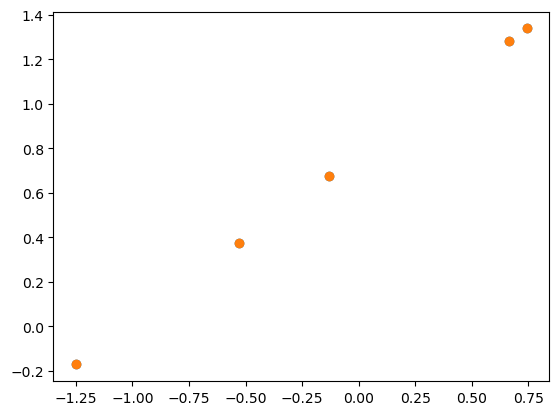

In [4]:
# Select top M eigenvectors
U_M = U[:, :M]

# Center data
X_centered = xs - x_bar

# Project
Z = X_centered @ U_M
X_reconstructed = Z @ U_M.T + x_bar

plt.scatter(*xtilde.T)
plt.scatter(*X_reconstructed.T)

## 4) (Score: 20%) You wish to project input data along one of the principal components obtained in the previous step. Which principal component would you choose and why?